<p align="center">
  <img src="https://www.portafolio.co/files/article_new_multimedia/uploads/2023/10/12/652828e536642.jpeg" style="width:100%; max-width:900px; height:180px; object-fit:cover; border-radius:10px;"/>
</p>
<div style="text-align:center;">
  <h1 style="color:#FFD700; display:inline-block; margin:0;">Optimización del Transporte en Nueva York</h1>
  <p>
    <b>Green Taxi | Machine Learning & Data Science | CRISP-DM</b><br>
    <span style="font-size:1.1em;">Análisis y predicción de tarifas y duración de viajes usando datos reales de taxis verdes de NYC.</span>
  </p>
</div>

In [1]:
# Verifica si las librerías necesarias ya están instaladas
try:
    # Ignorar warnings
    import warnings
    warnings.filterwarnings('ignore')

    # Librerías del sistema
    import sys, subprocess

    # Importaciones base
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os
    import joblib
    import scipy.stats as stats
    import pickle as pkl

    # Librerías de codificación y progreso
    import category_encoders as ce
    from tqdm import tqdm   

    # Librerías de preprocesamiento
    from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
    from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
    from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier)
    from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
    from sklearn.svm import SVC, SVR
    from sklearn.naive_bayes import GaussianNB
    from sklearn.neural_network import MLPRegressor, MLPClassifier
    from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler, PolynomialFeatures)
    from sklearn.impute import SimpleImputer, KNNImputer
    from sklearn.pipeline import make_pipeline
    from sklearn.model_selection import (train_test_split, GridSearchCV,RandomizedSearchCV, cross_val_score, cross_val_predict)
    from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,confusion_matrix, classification_report, roc_auc_score, roc_curve, calinski_harabasz_score)
    
    # Establece el tema global
    sns.set_theme(
    style="whitegrid",                  # El estilo del gráfico (fondo y cuadrícula)
        palette="colorblind",           # La paleta de colores
        font="sans-serif",               # La familia de la fuente
        font_scale=0.9,                  # Escala de la fuente
        rc={"axes.titlesize": 14, "axes.labelsize": 12, "xtick.labelsize": 10, "ytick.labelsize": 10}
    )
    
    print("Dependencias ya instaladas.")

except ImportError:

    print("Dependencias no encontradas. Instalando ahora...")
    
    # Se ejecutan los comandos de instalación
    %pip install --quiet matplotlib
    %pip install --quiet seaborn
    %pip install --quiet joblib
    %pip install --quiet scipy
    %pip install --quiet category_encoders
    %pip install --quiet tqdm
    
    print("Instalación completada.")

Dependencias ya instaladas.


In [2]:
# Función lambda para verificar e instalar
instalar = lambda p: subprocess.call([sys.executable, "-c", f"import {p}"]) and subprocess.call([sys.executable, "-m", "pip", "install", p, "-q"])

# Actualizar pip
subprocess.call([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "-q"])

# Verificar e instalar condicionalmente
if instalar("pyarrow") == 0: print("PyArrow instalado/verificado")
if instalar("fastparquet") == 0: print("FastParquet instalado/verificado")

print("Listo para usar")

PyArrow instalado/verificado
FastParquet instalado/verificado
Listo para usar


# 04.- Modeling

In [3]:
# Configuración del dataset desde el directorio local
parquet_file = "preparation_fare_green_tripdata_2025-06.parquet"
# Cargar el dataset de modelado
df_modeling_fare = pd.read_parquet(parquet_file, engine="pyarrow")

print("Dataset Cargado.")

Dataset Cargado.


In [4]:
df_modeling_fare.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49390 entries, 0 to 49389
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   VendorID                   49390 non-null  float64
 1   trip_type_1                49390 non-null  int64  
 2   trip_distance              49390 non-null  float64
 3   trip_duration_min          49390 non-null  float64
 4   fare_amount                49390 non-null  float64
 5   tolls_amount               49390 non-null  float64
 6   cbd_congestion_fee         49390 non-null  float64
 7   tip_amount                 49390 non-null  float64
 8   cost_per_minute_total      49390 non-null  float64
 9   surcharges_to_total_ratio  49390 non-null  float64
 10  total_amount               49390 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 4.5 MB


## Fare Amount Modeling 

In [5]:
# Objetivo
target_variable = 'fare_amount'
# Exclusión de variables
exclude_cols = [target_variable] 
features = [col for col in df_modeling_fare.select_dtypes(include=np.number).columns if col not in exclude_cols]
# División de datos
X = df_modeling_fare[features]
y = df_modeling_fare[target_variable]

print(f"Características seleccionadas para el modelado.")

Características seleccionadas para el modelado.


In [6]:
# División de datos en entrenamiento y prueba (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Datos divididos en conjuntos de entrenamiento y prueba.")

Datos divididos en conjuntos de entrenamiento y prueba.


In [7]:
# Importar modelos adicionales
from sklearn.linear_model import Lasso
from sklearn.neural_network import MLPRegressor

# Crear instancias de los modelos
# Linear
lr = LinearRegression()
#pf = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression()) 
# Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
dt = DecisionTreeRegressor(random_state=42)
# Knn
knn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1) # k=5 es un punto de partida común
ridge = Ridge(random_state=42)
lasso = Lasso(random_state=42)
# otros
#xgboost = GradientBoostingRegressor(random_state=42)
#svr = SVR(kernel='rbf', C=1.0)
neural_network = MLPRegressor(hidden_layer_sizes=(100,), random_state=42, max_iter=500)

# Definicion del diccionario de los modelos.
models_regression = {
    'LinearRegression': lr,
    #'PolynomialFeatures_LR': pf, 
    'RandomForest': rf,
    'DecisionTree': dt,
    'KNeighbors': knn,
    'Ridge': ridge,
    'Lasso': lasso,
    #'XGBoost': xgboost,
    #'SVR': svr,
    'NeuralNetwork': neural_network
}

print("Diccionario de modelos creado.")

Diccionario de modelos creado.


In [8]:
# Manejo de valores faltantes
# !!! Error de no tratamiento de valores faltantes ¡¡¡
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)
# !!! Error de no tratamiento de valores faltantes ¡¡¡

# Diccionario para almacenar resultados de métricas.
test_metrics_results = {}
# Ciclo de entrenamiento y evaluación de modelos
for name, model in models_regression.items():
    # Ajustar el modelo y hacer predicciones
    model.fit(X_train_imputed, y_train)
    y_pred_test = model.predict(X_test_imputed)

    # Calcular métricas en el set de prueba
    mae = mean_absolute_error(y_test, y_pred_test)
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred_test)

    # Almacenar resultados del set de prueba
    test_metrics_results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2
    }
    
    print(f"Evaluación completada para {name}.")

Evaluación completada para LinearRegression.
Evaluación completada para RandomForest.
Evaluación completada para DecisionTree.
Evaluación completada para KNeighbors.
Evaluación completada para Ridge.
Evaluación completada para Lasso.
Evaluación completada para NeuralNetwork.


In [9]:
# Mostrar Tabla de Comparación (Set de Prueba)
comparison_test_df = pd.DataFrame(test_metrics_results).T
# Imprimir la tabla en formato legible
print("\nTabla Comparativa de Métricas (Set de Prueba)")
print("---")
# Formato tabular para la impresión del DataFrame
print(f"{'Modelo':<20} | {'MAE':>12} | {'MSE':>12} | {'RMSE':>12} | {'R²':>10}")
print("-" * (20 + 3 + 12 + 3 + 12 + 3 + 12 + 3 + 10 + 2)) # Ajusta guiones
for index, row in comparison_test_df.sort_values(by='RMSE').iterrows(): # Ordenar por RMSE
    print(f"{index:<20} | {row['MAE']:>12.4f} | {row['MSE']:>12.4f} | {row['RMSE']:>12.4f} | {row['R²']:>10.4f}")
print("-" * (20 + 3 + 12 + 3 + 12 + 3 + 12 + 3 + 10 + 2))
print("---")


Tabla Comparativa de Métricas (Set de Prueba)
---
Modelo               |          MAE |          MSE |         RMSE |         R²
--------------------------------------------------------------------------------
RandomForest         |       0.2818 |       0.8682 |       0.9318 |     0.9949
NeuralNetwork        |       0.3816 |       1.2082 |       1.0992 |     0.9928
DecisionTree         |       0.3325 |       1.5171 |       1.2317 |     0.9910
KNeighbors           |       0.4023 |       1.7430 |       1.3202 |     0.9897
Ridge                |       1.4733 |      10.0985 |       3.1778 |     0.9401
LinearRegression     |       1.4731 |      10.1040 |       3.1787 |     0.9401
Lasso                |       4.3029 |      43.9445 |       6.6291 |     0.7394
--------------------------------------------------------------------------------
---


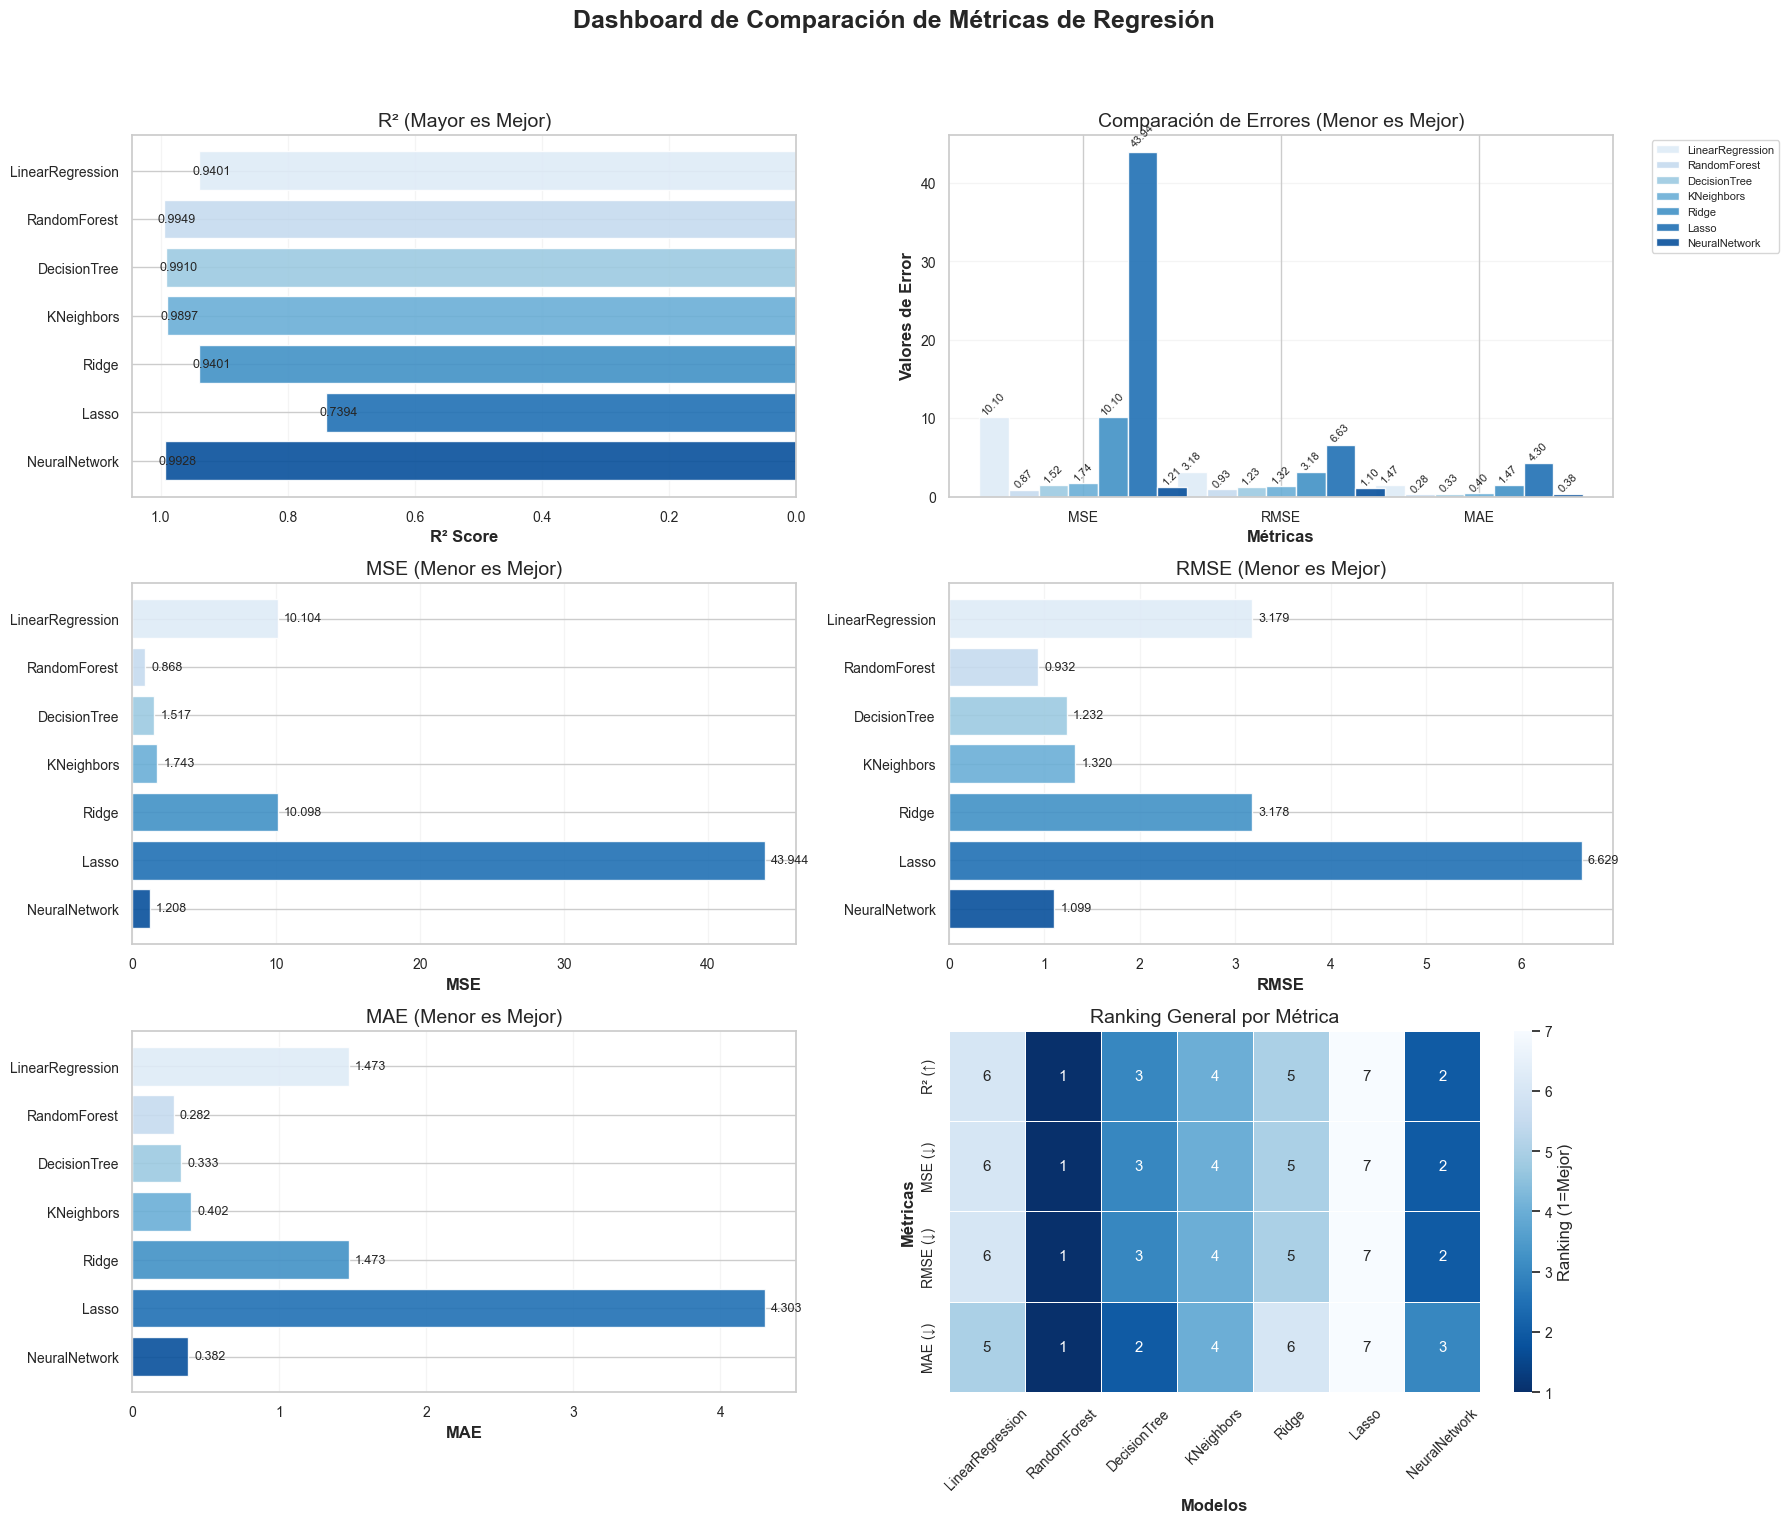

In [10]:
# --- Configuración del Dashboard ---
fig, axes = plt.subplots(3, 2, figsize=(18, 16)) # Mantenemos grid 3x2
fig.suptitle('Dashboard de Comparación de Métricas de Regresión', fontsize=18, fontweight='bold')

# Preparar datos comunes
models_names = list(test_metrics_results.keys())
colors = sns.color_palette("Blues", len(models_names))

# --- Gráfico 1 (NUEVO): R² Score (Independiente) ---
ax1 = axes[0, 0] # Posición superior izquierda
r2_scores = [test_metrics_results[name]['R²'] for name in models_names]
bars1 = ax1.barh(models_names, r2_scores, color=colors, alpha=0.9)
ax1.set_xlabel('R² Score', fontweight='bold')
ax1.set_title('R² (Mayor es Mejor)')
ax1.grid(True, alpha=0.2, axis='x')
# Etiquetas en barras horizontales
for bar, score in zip(bars1, r2_scores):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{score:.4f}',
             ha='left', va='center', fontsize=9)
ax1.invert_xaxis() # Opcional: para que la mejor barra (más larga) esté arriba si se ordena
ax1.invert_yaxis() # Para que los nombres de modelo coincidan con otras barras H

# --- Gráfico 2 (NUEVO): Comparación General (MSE, RMSE, MAE) ---
ax2 = axes[0, 1] # Posición superior derecha
metrics_compare = ['MSE', 'RMSE', 'MAE'] # Excluimos R²
x_pos = np.arange(len(metrics_compare))
width = 0.15 # Ajusta el ancho si es necesario

for i, (name, color) in enumerate(zip(models_names, colors)):
    # Obtener solo MSE, RMSE, MAE
    values = [test_metrics_results[name][metric] for metric in metrics_compare]
    bars2 = ax2.bar(x_pos + i * width, values, width, label=name, color=color, alpha=0.9, edgecolor='white')

    # Etiquetas en barras verticales (ajustadas)
    for bar, val in zip(bars2, values):
        height = bar.get_height()
        # Ajustar posición vertical para evitar solapamientos
        ax2.text(bar.get_x() + bar.get_width()/2., height * 1.01, f'{val:.2f}', # Usar .2f para errores
                 ha='center', va='bottom', fontsize=8, rotation=45)

ax2.set_xlabel('Métricas', fontweight='bold')
ax2.set_ylabel('Valores de Error', fontweight='bold')
ax2.set_title('Comparación de Errores (Menor es Mejor)')
ax2.set_xticks(x_pos + width * (len(models_names) - 1) / 2)
ax2.set_xticklabels(metrics_compare, rotation=0)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.2, axis='y')

# --- Gráfico 3: MSE (Individual) ---
ax3 = axes[1, 0] # Posición media izquierda
mse_scores = [test_metrics_results[name]['MSE'] for name in models_names]
bars3 = ax3.barh(models_names, mse_scores, color=colors, alpha=0.9)
ax3.set_xlabel('MSE', fontweight='bold')
ax3.set_title('MSE (Menor es Mejor)')
ax3.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars3, mse_scores):
    ax3.text(bar.get_width() + max(mse_scores)*0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', # Ajuste decimales
             ha='left', va='center', fontsize=9)
ax3.invert_yaxis() # Para alinear nombres

# --- Gráfico 4: RMSE (Individual) ---
ax4 = axes[1, 1] # Posición media derecha
rmse_scores = [test_metrics_results[name]['RMSE'] for name in models_names]
bars4 = ax4.barh(models_names, rmse_scores, color=colors, alpha=0.9)
ax4.set_xlabel('RMSE', fontweight='bold')
ax4.set_title('RMSE (Menor es Mejor)')
ax4.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars4, rmse_scores):
    ax4.text(bar.get_width() + max(rmse_scores)*0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
             ha='left', va='center', fontsize=9)
ax4.invert_yaxis() # Para alinear nombres

# --- Gráfico 5: MAE (Individual) ---
ax5 = axes[2, 0] # Posición inferior izquierda
mae_scores = [test_metrics_results[name]['MAE'] for name in models_names]
bars5 = ax5.barh(models_names, mae_scores, color=colors, alpha=0.9)
ax5.set_xlabel('MAE', fontweight='bold')
ax5.set_title('MAE (Menor es Mejor)')
ax5.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars5, mae_scores):
    ax5.text(bar.get_width() + max(mae_scores)*0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
             ha='left', va='center', fontsize=9)
ax5.invert_yaxis() # Para alinear nombres

# --- Gráfico 6: Ranking Heatmap (Independiente) ---
ax6 = axes[2, 1] # Posición inferior derecha
comparison_df = pd.DataFrame(test_metrics_results).T
# Usar todas las métricas originales para el ranking
metrics_all = ['R²', 'MSE', 'RMSE', 'MAE']
ranking_matrix = []
for metric in metrics_all:
    # Rankear R² descendente, errores ascendente
    ranked = comparison_df[metric].rank(ascending=(metric != 'R²'))
    ranking_matrix.append(ranked.values)

# Crear DataFrame del ranking
ranking_df = pd.DataFrame(ranking_matrix,
                          index=[f'{m} {"(↑)" if m=="R²" else "(↓)"}' for m in metrics_all],
                          columns=models_names)

sns.heatmap(ranking_df, annot=True, fmt='.0f', cmap='Blues_r', ax=ax6, # Usar Blues_r para que 1 sea oscuro
            cbar_kws={'label': 'Ranking (1=Mejor)'}, linewidths=.5)
ax6.set_title('Ranking General por Métrica')
ax6.set_xlabel('Modelos', fontweight='bold')
ax6.set_ylabel('Métricas', fontweight='bold')
# Rotar etiquetas X para evitar solapamiento
ax6.tick_params(axis='x', rotation=45)

# --- Ajuste Final ---
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar rect para dejar espacio al supertítulo
plt.show()

In [11]:

# Resumen Mejorado con Ranking Promedio
print("\nResumen de los Mejores Modelos")
best_models = {}
metrics_reg = ['MAE', 'MSE', 'RMSE', 'R²']
for metric in metrics_reg:
    if metric == 'R²':
        best = max(test_metrics_results.items(), key=lambda x: x[1][metric])
    else:
        best = min(test_metrics_results.items(), key=lambda x: x[1][metric])
    print(f"Mejor {metric:>4} {'(Mayor)':<7}: {best[0]:<20} = {best[1][metric]:.4f}")
    best_models[metric] = best[0]

# Ranking Promedio
avg_ranks = ranking_df.mean().sort_values()
print("\nRanking Promedio (Menor = Mejor General):")
for model, rank in avg_ranks.items():
    print(f"{model:<20}: {rank:.2f}")


Resumen de los Mejores Modelos
Mejor  MAE (Mayor): RandomForest         = 0.2818
Mejor  MSE (Mayor): RandomForest         = 0.8682
Mejor RMSE (Mayor): RandomForest         = 0.9318
Mejor   R² (Mayor): RandomForest         = 0.9949

Ranking Promedio (Menor = Mejor General):
RandomForest        : 1.00
NeuralNetwork       : 2.25
DecisionTree        : 2.75
KNeighbors          : 4.00
Ridge               : 5.25
LinearRegression    : 5.75
Lasso               : 7.00


In [12]:
# Define el nombre del archivo
modeling = 'modeling_fare_green_tripdata_2025-06.parquet'

# Guarda el DataFrame df_modeling en formato Parquet
try:
    df_modeling_fare.to_parquet(modeling, index=False) 
    print(f"DataFrame guardado exitosamente como '{modeling}'")
except Exception as e:
    print(f"Error al guardar como Parquet: {e}")

DataFrame guardado exitosamente como 'modeling_fare_green_tripdata_2025-06.parquet'


## Trip Duration in Minutes

In [13]:
# Configuración del dataset desde el directorio local
parquet_file = "preparation_trip_green_tripdata_2025-06.parquet"
# Cargar el dataset de modelado
df_modeling_trip = pd.read_parquet(parquet_file, engine="pyarrow")

print("Dataset Cargado.")

Dataset Cargado.


In [14]:
df_modeling_trip.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49390 entries, 0 to 49389
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_distance          49390 non-null  float64
 1   trip_duration_min      49390 non-null  float64
 2   improvement_surcharge  49390 non-null  float64
 3   cost_per_minute_total  49390 non-null  float64
dtypes: float64(4)
memory usage: 1.9 MB


In [15]:
target_variable = 'trip_duration_min'

exclude_cols = [target_variable] 
features = [col for col in df_modeling_trip.select_dtypes(include=np.number).columns if col not in exclude_cols]

X = df_modeling_trip[features]
y = df_modeling_trip[target_variable]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [17]:
# Importar modelos adicionales
from sklearn.linear_model import Lasso
from sklearn.neural_network import MLPRegressor

# Crear instancias de los modelos
# Linear
lr = LinearRegression()
#pf = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression()) 
# Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
dt = DecisionTreeRegressor(random_state=42)
# Knn
knn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1) # k=5 es un punto de partida común
ridge = Ridge(random_state=42)
lasso = Lasso(random_state=42)
# otros
#xgboost = GradientBoostingRegressor(random_state=42)
#svr = SVR(kernel='rbf', C=1.0)
neural_network = MLPRegressor(hidden_layer_sizes=(100,), random_state=42, max_iter=500)

# Definicion del diccionario de los modelos.
models_regression = {
    'LinearRegression': lr,
    #'PolynomialFeatures_LR': pf, 
    'RandomForest': rf,
    'DecisionTree': dt,
    'KNeighbors': knn,
    'Ridge': ridge,
    'Lasso': lasso,
    #'XGBoost': xgboost,
    #'SVR': svr,
    'NeuralNetwork': neural_network
}

print("Diccionario de modelos creado.")

Diccionario de modelos creado.


In [18]:
# Manejo de valores faltantes
# !!! Error de no tratamiento de valores faltantes ¡¡¡
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)
# !!! Error de no tratamiento de valores faltantes ¡¡¡

# Diccionario para almacenar resultados de métricas.
test_metrics_results = {}
# Ciclo de entrenamiento y evaluación de modelos
for name, model in models_regression.items():
    # Ajustar el modelo y hacer predicciones
    model.fit(X_train_imputed, y_train)
    y_pred_test = model.predict(X_test_imputed)

    # Calcular métricas en el set de prueba
    mae = mean_absolute_error(y_test, y_pred_test)
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred_test)

    # Almacenar resultados del set de prueba
    test_metrics_results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2
    }
    
    print(f"Evaluación completada para {name}.")

Evaluación completada para LinearRegression.
Evaluación completada para RandomForest.
Evaluación completada para DecisionTree.
Evaluación completada para KNeighbors.
Evaluación completada para Ridge.
Evaluación completada para Lasso.
Evaluación completada para NeuralNetwork.


In [19]:
# 6. Mostrar Tabla de Comparación (Set de Prueba)
comparison_test_df = pd.DataFrame(test_metrics_results).T # Transponer
print("\nTabla Comparativa de Métricas (Set de Prueba)")
print("---") # Separador Markdown

# Formato tabular para la impresión del DataFrame
print(f"{'Modelo':<20} | {'MAE':>12} | {'MSE':>12} | {'RMSE':>12} | {'R²':>10}")
print("-" * (20 + 3 + 12 + 3 + 12 + 3 + 12 + 3 + 10 + 2)) # Ajusta guiones
for index, row in comparison_test_df.sort_values(by='RMSE').iterrows(): # Ordenar por RMSE
    print(f"{index:<20} | {row['MAE']:>12.4f} | {row['MSE']:>12.4f} | {row['RMSE']:>12.4f} | {row['R²']:>10.4f}")
print("-" * (20 + 3 + 12 + 3 + 12 + 3 + 12 + 3 + 10 + 2))
print("---") # Separador Markdown


Tabla Comparativa de Métricas (Set de Prueba)
---
Modelo               |          MAE |          MSE |         RMSE |         R²
--------------------------------------------------------------------------------
RandomForest         |       0.0022 |       0.0000 |       0.0067 |     0.9706
DecisionTree         |       0.0027 |       0.0001 |       0.0088 |     0.9482
NeuralNetwork        |       0.0037 |       0.0001 |       0.0118 |     0.9073
KNeighbors           |       0.0027 |       0.0002 |       0.0124 |     0.8987
LinearRegression     |       0.0088 |       0.0013 |       0.0357 |     0.1551
Ridge                |       0.0088 |       0.0013 |       0.0357 |     0.1550
Lasso                |       0.0086 |       0.0015 |       0.0388 |    -0.0001
--------------------------------------------------------------------------------
---


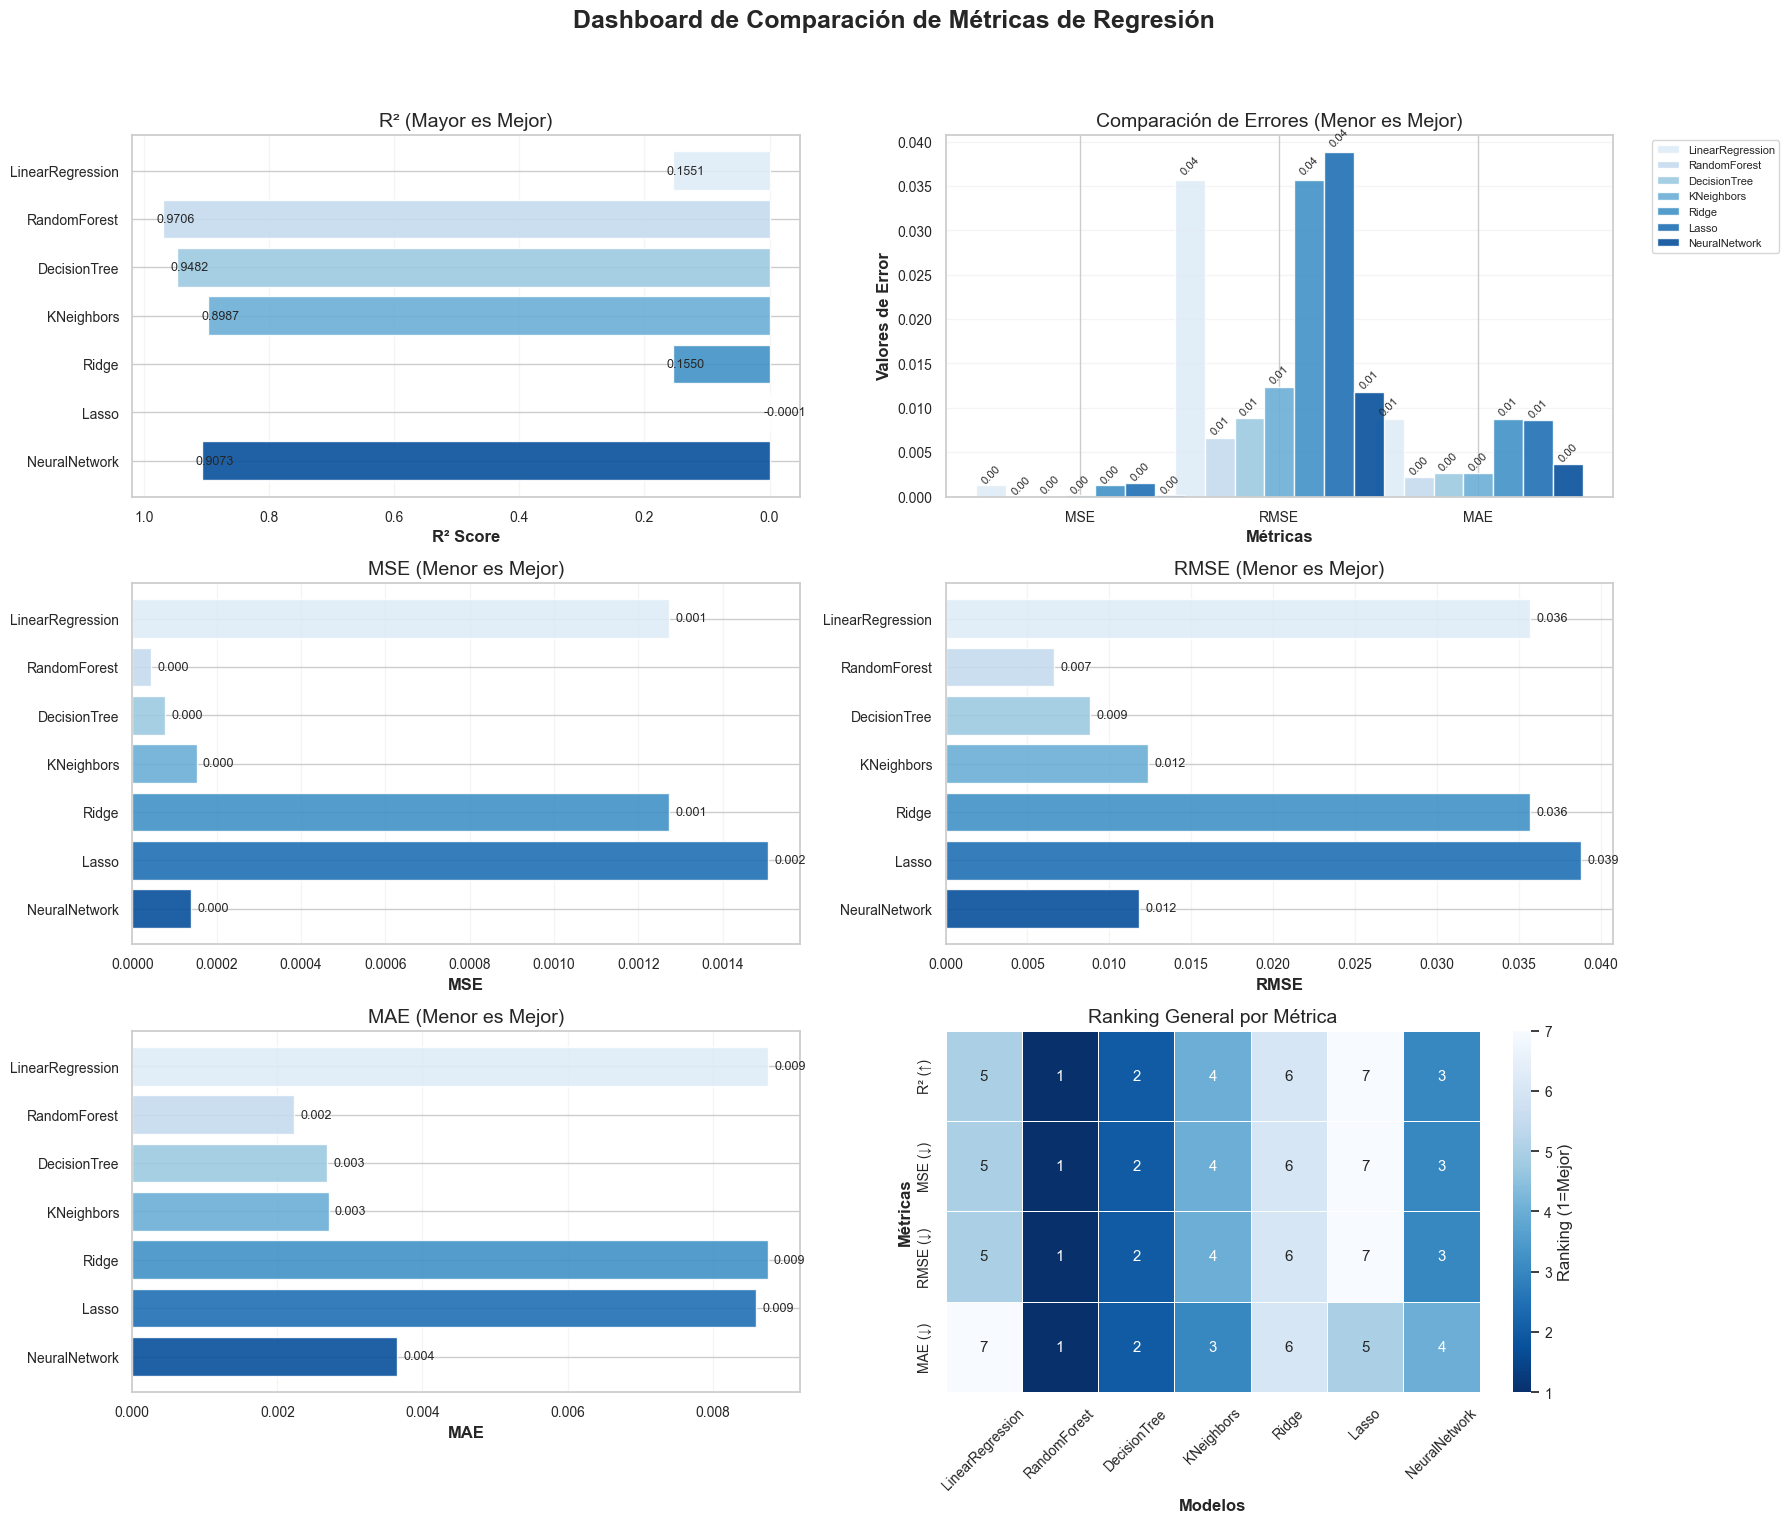

In [20]:
# --- Configuración del Dashboard ---
fig, axes = plt.subplots(3, 2, figsize=(18, 16)) # Mantenemos grid 3x2
fig.suptitle('Dashboard de Comparación de Métricas de Regresión', fontsize=18, fontweight='bold')

# Preparar datos comunes
models_names = list(test_metrics_results.keys())
colors = sns.color_palette("Blues", len(models_names))

# --- Gráfico 1 (NUEVO): R² Score (Independiente) ---
ax1 = axes[0, 0] # Posición superior izquierda
r2_scores = [test_metrics_results[name]['R²'] for name in models_names]
bars1 = ax1.barh(models_names, r2_scores, color=colors, alpha=0.9)
ax1.set_xlabel('R² Score', fontweight='bold')
ax1.set_title('R² (Mayor es Mejor)')
ax1.grid(True, alpha=0.2, axis='x')
# Etiquetas en barras horizontales
for bar, score in zip(bars1, r2_scores):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{score:.4f}',
             ha='left', va='center', fontsize=9)
ax1.invert_xaxis() # Opcional: para que la mejor barra (más larga) esté arriba si se ordena
ax1.invert_yaxis() # Para que los nombres de modelo coincidan con otras barras H

# --- Gráfico 2 (NUEVO): Comparación General (MSE, RMSE, MAE) ---
ax2 = axes[0, 1] # Posición superior derecha
metrics_compare = ['MSE', 'RMSE', 'MAE'] # Excluimos R²
x_pos = np.arange(len(metrics_compare))
width = 0.15 # Ajusta el ancho si es necesario

for i, (name, color) in enumerate(zip(models_names, colors)):
    # Obtener solo MSE, RMSE, MAE
    values = [test_metrics_results[name][metric] for metric in metrics_compare]
    bars2 = ax2.bar(x_pos + i * width, values, width, label=name, color=color, alpha=0.9, edgecolor='white')

    # Etiquetas en barras verticales (ajustadas)
    for bar, val in zip(bars2, values):
        height = bar.get_height()
        # Ajustar posición vertical para evitar solapamientos
        ax2.text(bar.get_x() + bar.get_width()/2., height * 1.01, f'{val:.2f}', # Usar .2f para errores
                 ha='center', va='bottom', fontsize=8, rotation=45)

ax2.set_xlabel('Métricas', fontweight='bold')
ax2.set_ylabel('Valores de Error', fontweight='bold')
ax2.set_title('Comparación de Errores (Menor es Mejor)')
ax2.set_xticks(x_pos + width * (len(models_names) - 1) / 2)
ax2.set_xticklabels(metrics_compare, rotation=0)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.2, axis='y')

# --- Gráfico 3: MSE (Individual) ---
ax3 = axes[1, 0] # Posición media izquierda
mse_scores = [test_metrics_results[name]['MSE'] for name in models_names]
bars3 = ax3.barh(models_names, mse_scores, color=colors, alpha=0.9)
ax3.set_xlabel('MSE', fontweight='bold')
ax3.set_title('MSE (Menor es Mejor)')
ax3.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars3, mse_scores):
    ax3.text(bar.get_width() + max(mse_scores)*0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', # Ajuste decimales
             ha='left', va='center', fontsize=9)
ax3.invert_yaxis() # Para alinear nombres

# --- Gráfico 4: RMSE (Individual) ---
ax4 = axes[1, 1] # Posición media derecha
rmse_scores = [test_metrics_results[name]['RMSE'] for name in models_names]
bars4 = ax4.barh(models_names, rmse_scores, color=colors, alpha=0.9)
ax4.set_xlabel('RMSE', fontweight='bold')
ax4.set_title('RMSE (Menor es Mejor)')
ax4.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars4, rmse_scores):
    ax4.text(bar.get_width() + max(rmse_scores)*0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
             ha='left', va='center', fontsize=9)
ax4.invert_yaxis() # Para alinear nombres

# --- Gráfico 5: MAE (Individual) ---
ax5 = axes[2, 0] # Posición inferior izquierda
mae_scores = [test_metrics_results[name]['MAE'] for name in models_names]
bars5 = ax5.barh(models_names, mae_scores, color=colors, alpha=0.9)
ax5.set_xlabel('MAE', fontweight='bold')
ax5.set_title('MAE (Menor es Mejor)')
ax5.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars5, mae_scores):
    ax5.text(bar.get_width() + max(mae_scores)*0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
             ha='left', va='center', fontsize=9)
ax5.invert_yaxis() # Para alinear nombres

# --- Gráfico 6: Ranking Heatmap (Independiente) ---
ax6 = axes[2, 1] # Posición inferior derecha
comparison_df = pd.DataFrame(test_metrics_results).T
# Usar todas las métricas originales para el ranking
metrics_all = ['R²', 'MSE', 'RMSE', 'MAE']
ranking_matrix = []
for metric in metrics_all:
    # Rankear R² descendente, errores ascendente
    ranked = comparison_df[metric].rank(ascending=(metric != 'R²'))
    ranking_matrix.append(ranked.values)

# Crear DataFrame del ranking
ranking_df = pd.DataFrame(ranking_matrix,
                          index=[f'{m} {"(↑)" if m=="R²" else "(↓)"}' for m in metrics_all],
                          columns=models_names)

sns.heatmap(ranking_df, annot=True, fmt='.0f', cmap='Blues_r', ax=ax6, # Usar Blues_r para que 1 sea oscuro
            cbar_kws={'label': 'Ranking (1=Mejor)'}, linewidths=.5)
ax6.set_title('Ranking General por Métrica')
ax6.set_xlabel('Modelos', fontweight='bold')
ax6.set_ylabel('Métricas', fontweight='bold')
# Rotar etiquetas X para evitar solapamiento
ax6.tick_params(axis='x', rotation=45)

# --- Ajuste Final ---
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar rect para dejar espacio al supertítulo
plt.show()

In [21]:
# Resumen Mejorado con Ranking Promedio
print("\nResumen de los Mejores Modelos")
best_models = {}
metrics_reg = ['MAE', 'MSE', 'RMSE', 'R²']
for metric in metrics_reg:
    if metric == 'R²':
        best = max(test_metrics_results.items(), key=lambda x: x[1][metric])
    else:
        best = min(test_metrics_results.items(), key=lambda x: x[1][metric])
    print(f"Mejor {metric:>4} {'(Mayor)':<7}: {best[0]:<20} = {best[1][metric]:.4f}")
    best_models[metric] = best[0]

# Ranking Promedio
avg_ranks = ranking_df.mean().sort_values()
print("\nRanking Promedio (Menor = Mejor General):")
for model, rank in avg_ranks.items():
    print(f"{model:<20}: {rank:.2f}")


Resumen de los Mejores Modelos
Mejor  MAE (Mayor): RandomForest         = 0.0022
Mejor  MSE (Mayor): RandomForest         = 0.0000
Mejor RMSE (Mayor): RandomForest         = 0.0067
Mejor   R² (Mayor): RandomForest         = 0.9706

Ranking Promedio (Menor = Mejor General):
RandomForest        : 1.00
DecisionTree        : 2.00
NeuralNetwork       : 3.25
KNeighbors          : 3.75
LinearRegression    : 5.50
Ridge               : 6.00
Lasso               : 6.50


In [22]:
# Define el nombre del archivo
modeling = 'modeling_trip_green_tripdata_2025-06.parquet'

# Guarda el DataFrame df_modeling en formato Parquet
try:
    df_modeling_trip.to_parquet(modeling, index=False) 
    print(f"DataFrame guardado exitosamente como '{modeling}'")
except Exception as e:
    print(f"Error al guardar como Parquet: {e}")

DataFrame guardado exitosamente como 'modeling_trip_green_tripdata_2025-06.parquet'
